In [3]:
import yt
import numpy as np
from yt.frontends.boxlib.api import NyxDataset, AMReXDataset
from yt.data_objects.time_series import DatasetSeries
import matplotlib.pyplot as plt
from matplotlib import rc_context
from matplotlib.animation import FuncAnimation
from IPython import display

In [4]:
class AMReXDatasetSeries(DatasetSeries):
    _dataset_cls = AMReXDataset

In [5]:
path = "../plt00002"
ds = AMReXDataset(path)

yt : [INFO     ] 2025-03-10 04:15:51,632 Parameters: current_time              = 0.1
yt : [INFO     ] 2025-03-10 04:15:51,633 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2025-03-10 04:15:51,634 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-03-10 04:15:51,634 Parameters: domain_right_edge         = [200. 200. 200.]


In [6]:
ds.field_list

[('boxlib', 'density'), ('boxlib', 'phi_grav')]

In [7]:
def get_yt_density_x_array(ds):
    Lbox = ds.domain_width[0].value
    x = np.linspace(0, Lbox, ds.domain_dimensions[0], endpoint=False)
    xcoords =[(xi, 100, 100) for xi in x]
    Density = ds.find_field_values_at_points([('boxlib', 'density')], xcoords)
    return x, Density

def get_yt_phi_x_array(ds):
    Lbox = ds.domain_width[0].value
    x = np.linspace(0, Lbox, ds.domain_dimensions[0], endpoint=False)
    xcoords =[(xi, 100, 100) for xi in x]
    Phi = ds.find_field_values_at_points([('boxlib', 'phi_grav')], xcoords)
    return x, Phi

In [8]:
x, numm_rho = get_yt_density_x_array(ds)
x, numm_phi = get_yt_phi_x_array(ds)

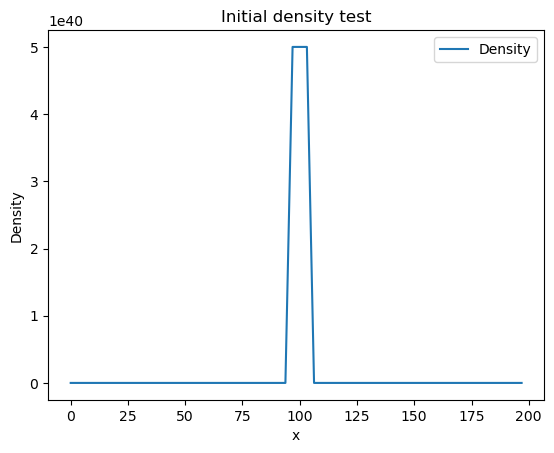

In [9]:
fig, ax = plt.subplots()
ax.plot(x, numm_rho, label='Density')
ax.set_title('Initial density test')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.legend()
plt.show()

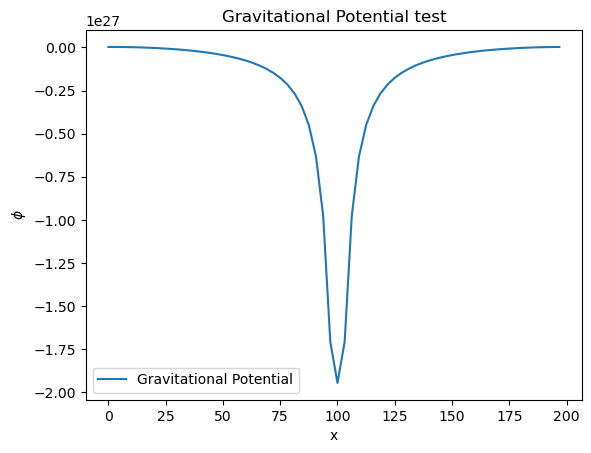

In [14]:
fig, ax = plt.subplots()
#ax.plot(x, np.abs(numm_phi), label='Gravitational Potential')
ax.plot(x, numm_phi, label='Gravitational Potential')
ax.set_title('Gravitational Potential test')
ax.set_xlabel(r'x')
ax.set_ylabel(r'$\phi$')
ax.legend()
#plt.yscale("log")
plt.show()

In [11]:
zero_point = [10, 10, 10]
density_zero_value = ds.r[zero_point]["density"]

print("Density at (10, 10, 10):", density_zero_value)

one_point = [15, 10, 10]
density_one_value = ds.r[one_point]["density"]

print("Density at (15, 10, 10):", density_one_value)

two_point = [0, 10, 10]
density_two_value = ds.r[two_point]["density"]

print("Density at (0, 10, 10):", density_two_value)

Density at (10, 10, 10): [0.] g/cm**3
Density at (15, 10, 10): [0.] g/cm**3
Density at (0, 10, 10): [0.] g/cm**3


In [12]:
min_point = [100, 100, 100]
min_phi_value = ds.r[min_point]["phi_grav"]

print("Gravitational potential value at the center of sphere(simulation):", min_phi_value)

sphere_point = [105, 100, 100]
sphere_phi_value = ds.r[sphere_point]["phi_grav"]

print("Gravitational potential value at the shell of sphere(simulation):", sphere_phi_value)

max_point = [0, 100, 100]
max_phi_value = ds.r[max_point]["phi_grav"]

print("Gravitational potential value at the edge of the box(simulation):", max_phi_value)

# Define code units
M_unit = 1.98848e33      # 1 M_sun = 1.98848e33 g
L_unit = 3.0856776e24    # 1 Mpc = 3.0856776e24 cm
V_unit = 1.0e5           # 1 km/s = 1.0e5 cm/s
T_unit = L_unit/V_unit

# Define constants/parameters
G_CGS = 6.67428e-8      # cm^3/g/s^2
R_unknown = 2.5         # unknown unit

G_cos = G_CGS * M_unit * T_unit * T_unit /(L_unit * L_unit * L_unit) # (km/s)^2 Mpc / Msun
rho_cos = 5e40          # Msun / Mpc^3

print ("new unit G [(km/s)^2 Mpc / Msun] :", G_cos)
print ("new unit rho [Msun/ Mpc^3]:", rho_cos)

Gravitational potential value at the center of sphere(simulation): [-1.9460731e+27] dimensionless
Gravitational potential value at the shell of sphere(simulation): [-1.70837198e+27] dimensionless
Gravitational potential value at the edge of the box(simulation): [3.16995727e+24] dimensionless
new unit G [(km/s)^2 Mpc / Msun] : 4.301056044999647e-09
new unit rho [Msun/ Mpc^3]: 5e+40


In [13]:
k1 = G_cos * rho_cos * R_unknown**2 * (- 2 * np.pi)
k2 = G_cos * rho_cos * R_unknown**2 * (- (4/3) * np.pi)

print("Gravitational potential value at the center of sphere(analytic) :", k1)
print("Gravitational potential value at the shell of sphere(analytic):", k2)

print("Difference at the center of sphere(analytic) :", min_phi_value - k1)
print("Difference at the shell of sphere(analytic):", sphere_phi_value - k2)

Gravitational potential value at the center of sphere(analytic) : -8.445103796030538e+33
Gravitational potential value at the shell of sphere(analytic): -5.630069197353693e+33
Difference at the center of sphere(analytic) : [8.44510185e+33] dimensionless
Difference at the shell of sphere(analytic): [5.63006749e+33] dimensionless
